# Heart Disease Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, balanced_accuracy_score


import torch
from sklearn.metrics import accuracy_score
import shap

import torch.nn as nn
import torch.optim as optim

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


import os
import random

def set_seed(seed=29):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Enable deterministic ops in TF if using GPU
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(29)


## Part 1: Heart Disease Prediction Dataset (20 Pts)

### Q1: Exploratory Data Analysis (3 Pts)
1. **Exploring the Dataset**  
    - Explore features, their distribution, and labels (Q1.1. [1 Pt]). It 
2. **Handling Data Issues**  
    - Check for missing/nonsensical data, unusual distributions, outliers, or class imbalance (Q1.2. [1 Pt]): Cholesterol and Oldpeak have 0 values that is most likely default values if the data is missing. There are more heart disease patients than no heart disease. There are also more men in the dataset than women, which could lead to a strong bias due to their physiology. There are no Nans in the dataset.
    - Describe how to handle these issues: One way would to be to replace the 0s in Cholesterol and Oldpeak by the mean for example. To handle the sex imbalance we could set class weights in our loss function so that mistakes on the minority class (e.g., women) are penalized more heavily than mistakes on the majority class.
3. **Preprocessing**  
    - Explain preprocessing steps for subsequent tasks (Q1.3. [1 Pt]).


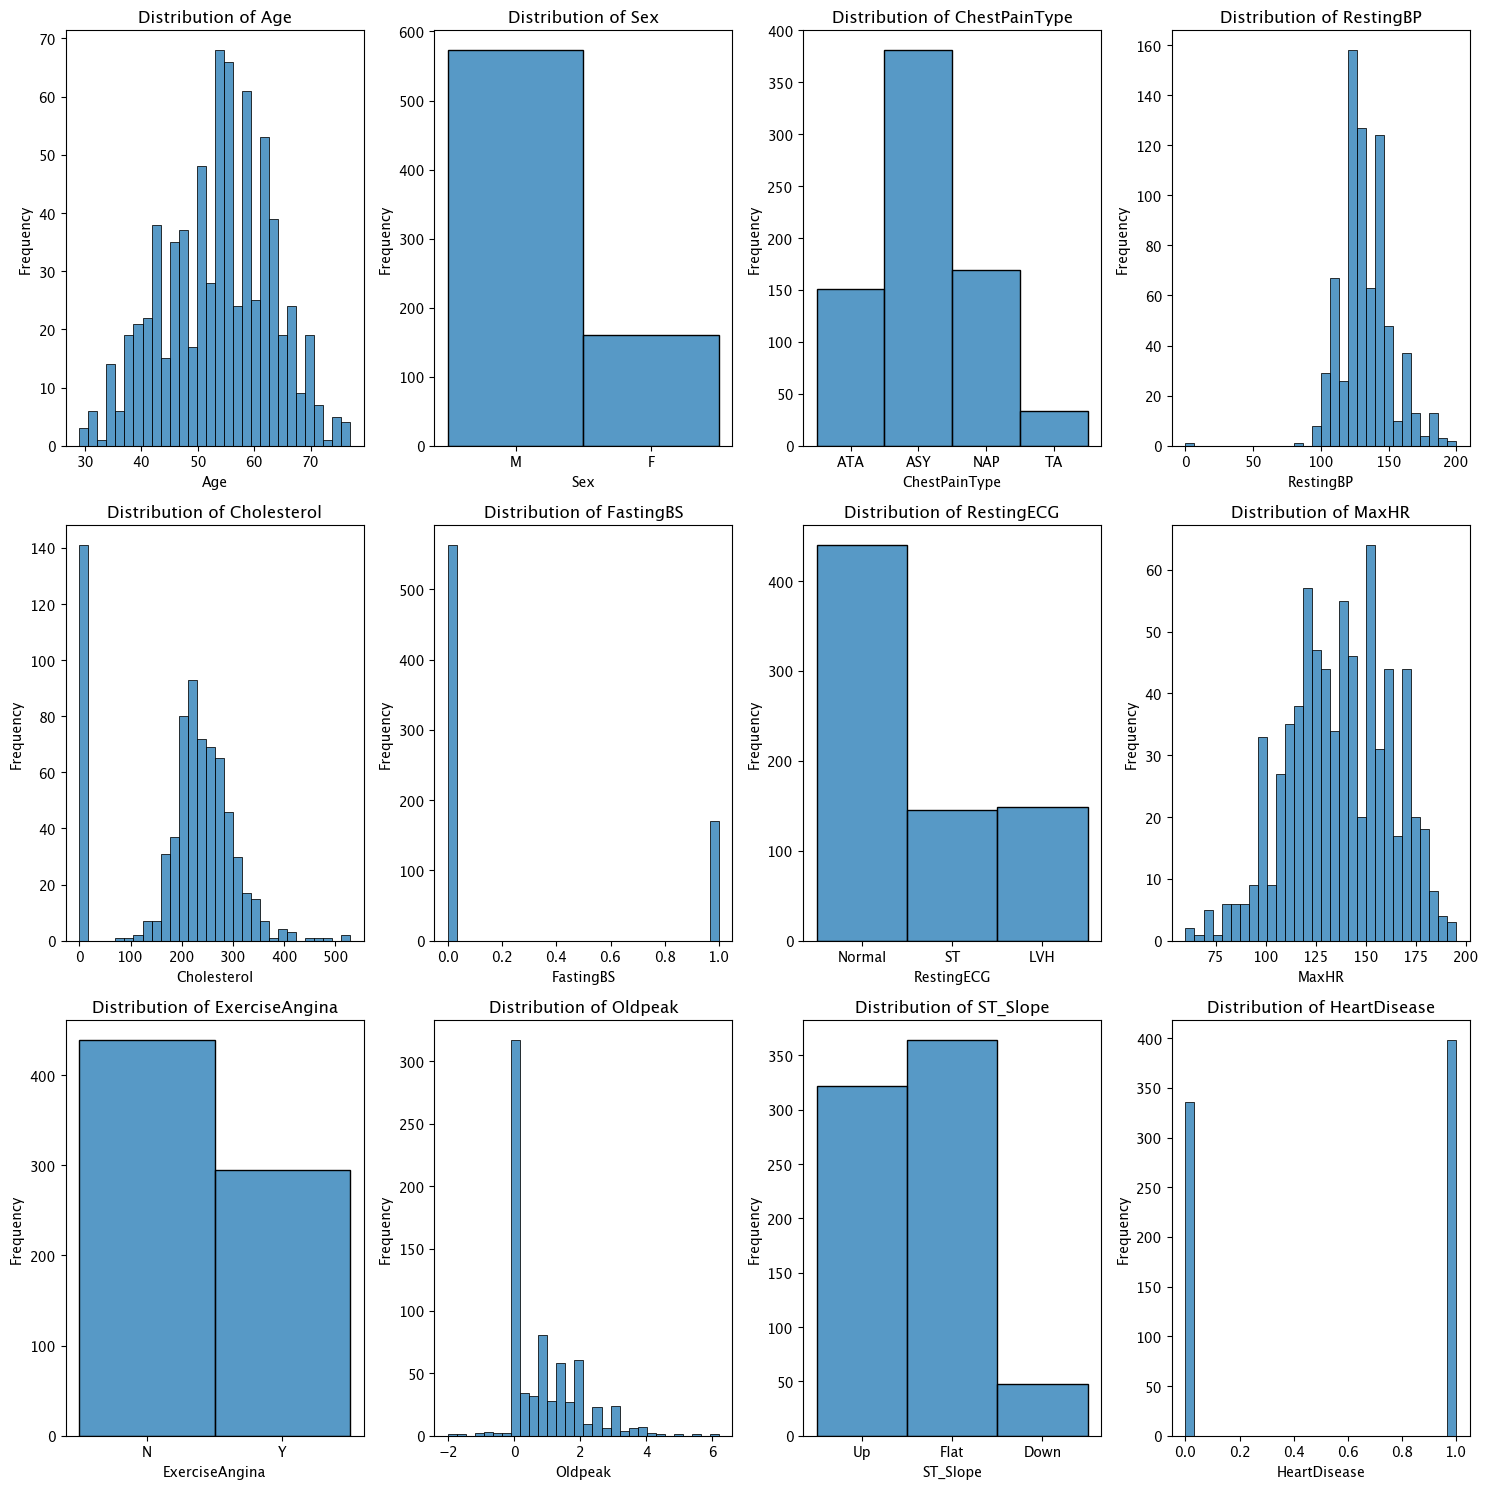

In [2]:
def load_data():
    # Load the datasets
    train_val_data = pd.read_csv('heart_failure_data/train_val_split.csv')
    test_data = pd.read_csv('heart_failure_data/test_split.csv')
    return train_val_data, test_data

train_val_data, test_data = load_data()

# Load the datasets
train_val_data = pd.read_csv('heart_failure_data/train_val_split.csv')
test_data = pd.read_csv('heart_failure_data/test_split.csv')

# Plot feature distributions in a single figure with 3 columns
num_features = len(train_val_data.columns) - 1  # Exclude 'HeartDisease'
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, column in enumerate(train_val_data.columns):
    sns.histplot(train_val_data[column], kde=False, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### Q2: Logistic Lasso Regression (5 Pts)
1. **Model Fitting**  
    - Fit a Lasso regression model with l1 regularization (Q2.1. [1 Pt]).


In [3]:

def get_x_y(data):
    # Separate features and target variable
    X = data.drop(columns=['HeartDisease'])
    y = data['HeartDisease']
    return X, y

2. **Preprocessing for Comparability**  
    - Describe crucial preprocessing steps (Q2.2. [1 Pt]).

In our preprocessing, we performed three main steps:

1. In the dataset, we replaced 0 values in cholesterol and oldpeak with the median within each gender group, because 0 is physiologically improbable for cholesterol and suspicious for oldpeak.

2. We applied one-hot encoding to columns like restecg, ST_slope and ChestpainType, using drop_first=True to avoid multicollinearity problems in logistic regression.

3. We used StandardScaler to standardize continuous features like age, resting blood pressure, cholesterol, maximum heart rate, and oldpeak, because logistic regression performs better when inputs are on similar scales.


  


### Log Reg with Preprocessed Data

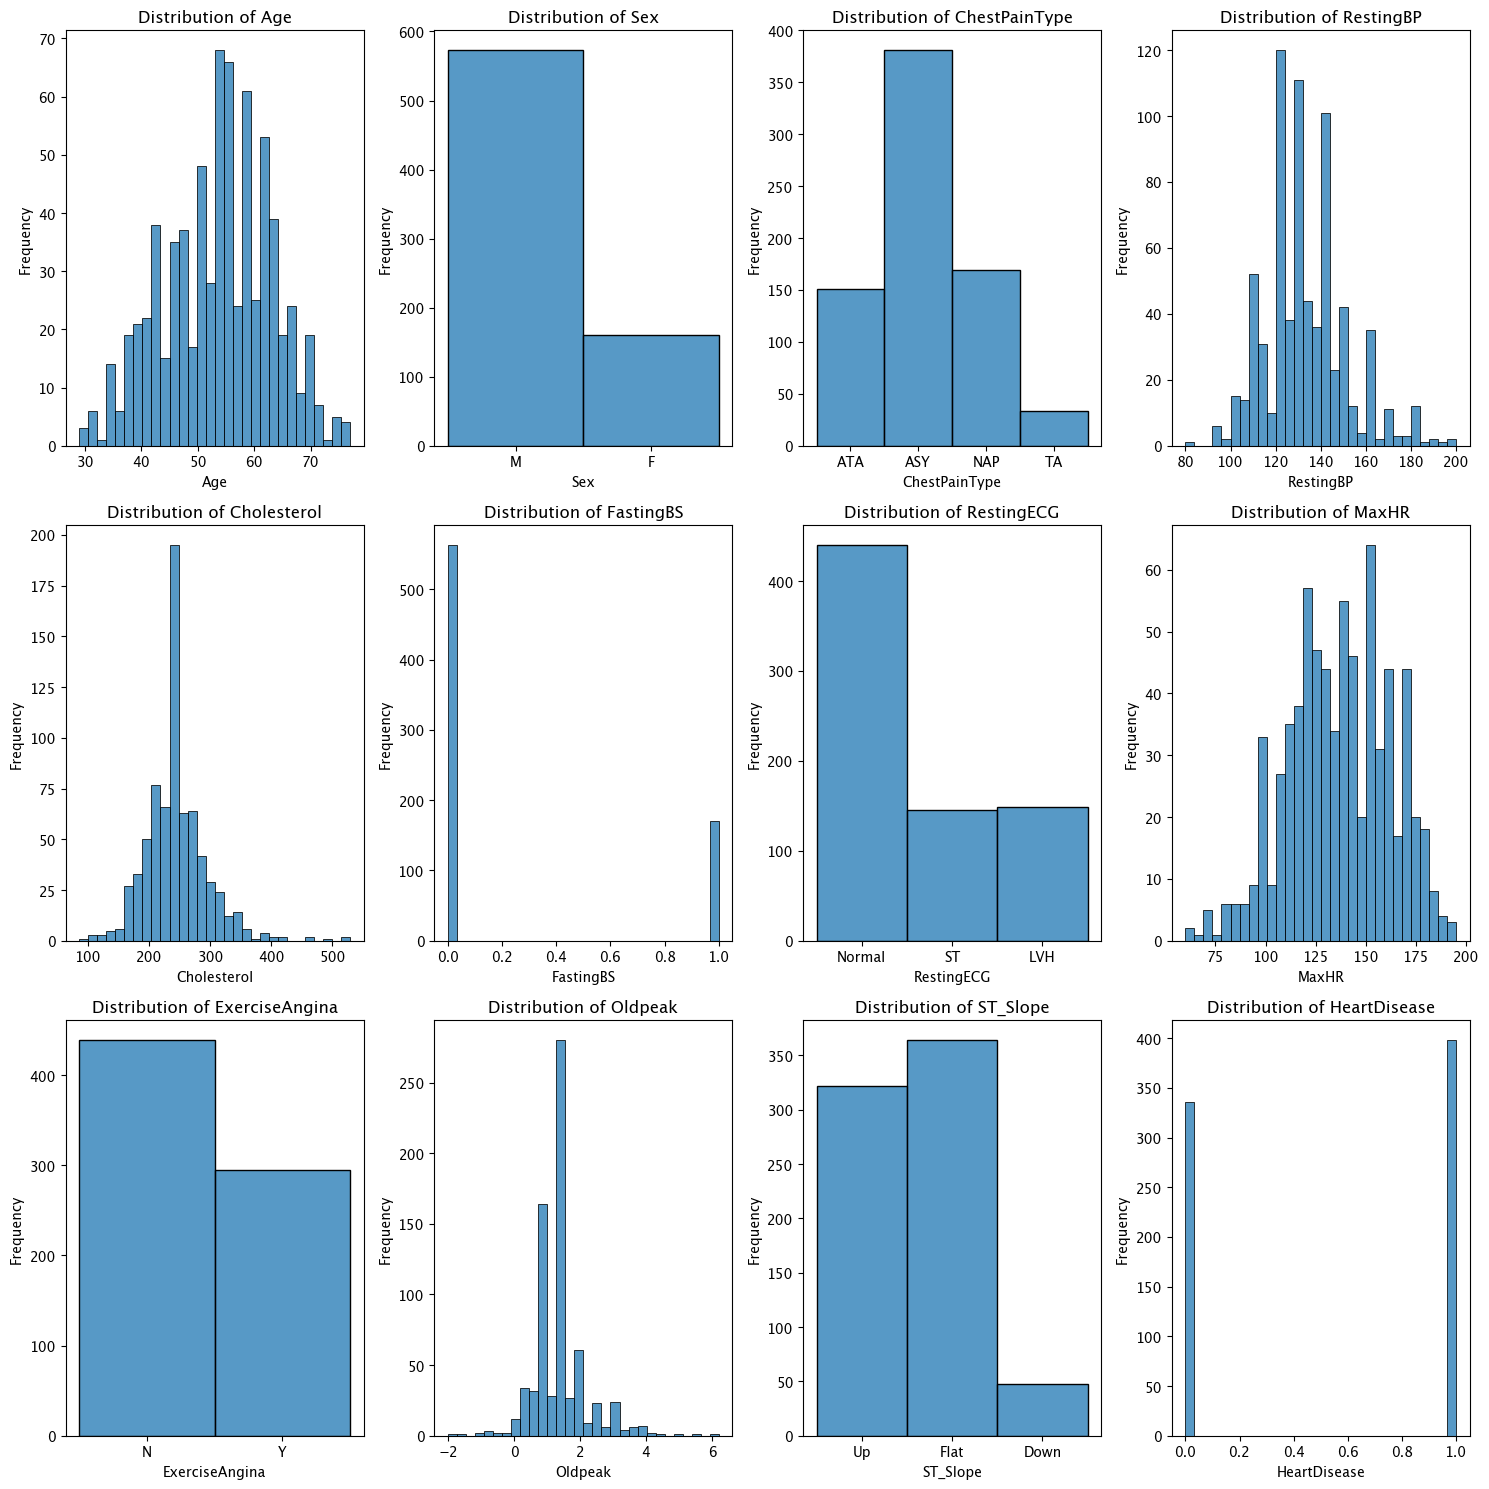

              precision    recall  f1-score   support

           0       0.81      0.30      0.44        74
           1       0.67      0.95      0.79       110

    accuracy                           0.69       184
   macro avg       0.74      0.63      0.61       184
weighted avg       0.73      0.69      0.65       184

0.6902173913043478
Balanced Accuracy: 0.63
F1-Score: 0.79


In [4]:
def preprocess_data(train_val_data, test_data):
    # Replace 0s in Cholesterol and Oldpeak in train/val set by the median within each Sex group
    train_val_data['Cholesterol'] = train_val_data['Cholesterol'].replace(0, np.nan)
    train_val_data['Oldpeak'] = train_val_data['Oldpeak'].replace(0, np.nan)
    train_val_data['RestingBP'] = train_val_data['RestingBP'].replace(0, np.nan)

    train_val_data['Cholesterol'] = train_val_data.groupby('Sex')['Cholesterol'].transform(lambda x: x.fillna(x.median()))
    train_val_data['Oldpeak'] = train_val_data.groupby('Sex')['Oldpeak'].transform(lambda x: x.fillna(x.median()))
    train_val_data['RestingBP'] = train_val_data.groupby('Sex')['RestingBP'].transform(lambda x: x.fillna(x.median()))

    # Step 1: Replace 0 with NaN
    train_val_data['Cholesterol'] = train_val_data['Cholesterol'].replace(0, np.nan)
    train_val_data['Oldpeak'] = train_val_data['Oldpeak'].replace(0, np.nan)
    train_val_data['RestingBP'] = train_val_data['RestingBP'].replace(0, np.nan)

    test_data['Cholesterol'] = test_data['Cholesterol'].replace(0, np.nan)
    test_data['Oldpeak'] = test_data['Oldpeak'].replace(0, np.nan)
    test_data['RestingBP'] = test_data['RestingBP'].replace(0, np.nan)

    # Step 2: Compute medians only on train_val_data
    medians_cholesterol = train_val_data.groupby('Sex')['Cholesterol'].median()
    medians_oldpeak = train_val_data.groupby('Sex')['Oldpeak'].median()
    medians_oldpeak = train_val_data.groupby('Sex')['RestingBP'].median()

    # Step 3: Fill NaNs in train set
    train_val_data['Cholesterol'] = train_val_data.apply(
        lambda row: medians_cholesterol[row['Sex']] if pd.isna(row['Cholesterol']) else row['Cholesterol'],
        axis=1
    )
    train_val_data['Oldpeak'] = train_val_data.apply(
        lambda row: medians_oldpeak[row['Sex']] if pd.isna(row['Oldpeak']) else row['Oldpeak'],
        axis=1
    )
    train_val_data['RestingBP'] = train_val_data.apply(
        lambda row: medians_oldpeak[row['Sex']] if pd.isna(row['Oldpeak']) else row['RestingBP'],
        axis=1
    )

    # Step 4: Fill NaNs in test set using same medians
    test_data['Cholesterol'] = test_data.apply(
        lambda row: medians_cholesterol[row['Sex']] if pd.isna(row['Cholesterol']) else row['Cholesterol'],
        axis=1
    )
    test_data['Oldpeak'] = test_data.apply(
        lambda row: medians_oldpeak[row['Sex']] if pd.isna(row['Oldpeak']) else row['Oldpeak'],
        axis=1
    )
    test_data['RestingBP'] = test_data.apply(
        lambda row: medians_oldpeak[row['Sex']] if pd.isna(row['RestingBP']) else row['RestingBP'],
        axis=1
    )
    return train_val_data, test_data

train_val_data, test_data = load_data()
preprocessed_train_val_data, preprocessed_test_data = preprocess_data(train_val_data, test_data)

# Plot feature distributions in a single figure with 3 columns
num_features = len(preprocessed_train_val_data.columns) - 1  # Exclude 'HeartDisease'
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, column in enumerate(preprocessed_train_val_data.columns):
    sns.histplot(preprocessed_train_val_data[column], kde=False, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

X_train_val, y_train_val = get_x_y(preprocessed_train_val_data)
X_test, y_test = get_x_y(preprocessed_test_data)

# One-hot encode categorical variables
X_train_val_df = pd.get_dummies(X_train_val, drop_first=True)
X_test_df = pd.get_dummies(X_test, drop_first=True)
# After one-hot encoding but BEFORE StandardScaler
gender_train_val = X_train_val_df["Sex_M"].values  # Still a DataFrame here

# Standardize the features
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val_df)
X_test = scaler.transform(X_test_df)

# Fit a Lasso regression model
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=29)
lasso_model.fit(X_train_val, y_train_val)

# Evaluate the model
y_pred = lasso_model.predict(X_test)
print(classification_report(y_test, y_pred))

print(accuracy_score(y_test, y_pred))
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.2f}")

# Calculate f1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.2f}")

In [5]:
# Add the predicted values to the test data
test_data['Predicted'] = y_pred.flatten().astype(int)

# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")

Performance metrics for Sex = M:
              precision    recall  f1-score   support

           0       0.79      0.28      0.42        53
           1       0.71      0.96      0.82        99

    accuracy                           0.72       152
   macro avg       0.75      0.62      0.62       152
weighted avg       0.74      0.72      0.68       152

Balanced Accuracy for Sex = M: 0.62
Performance metrics for Sex = F:
              precision    recall  f1-score   support

           0       0.88      0.33      0.48        21
           1       0.42      0.91      0.57        11

    accuracy                           0.53        32
   macro avg       0.65      0.62      0.53        32
weighted avg       0.72      0.53      0.51        32

Balanced Accuracy for Sex = F: 0.62


3. **Performance Metrics**  
    - Report metrics like f1-score or balanced accuracy (Q2.3. [1 Pt]).



4. **Feature Importance Visualization**  
    - Visualize feature importance and explain contributions (Q2.4. [1 Pt]).


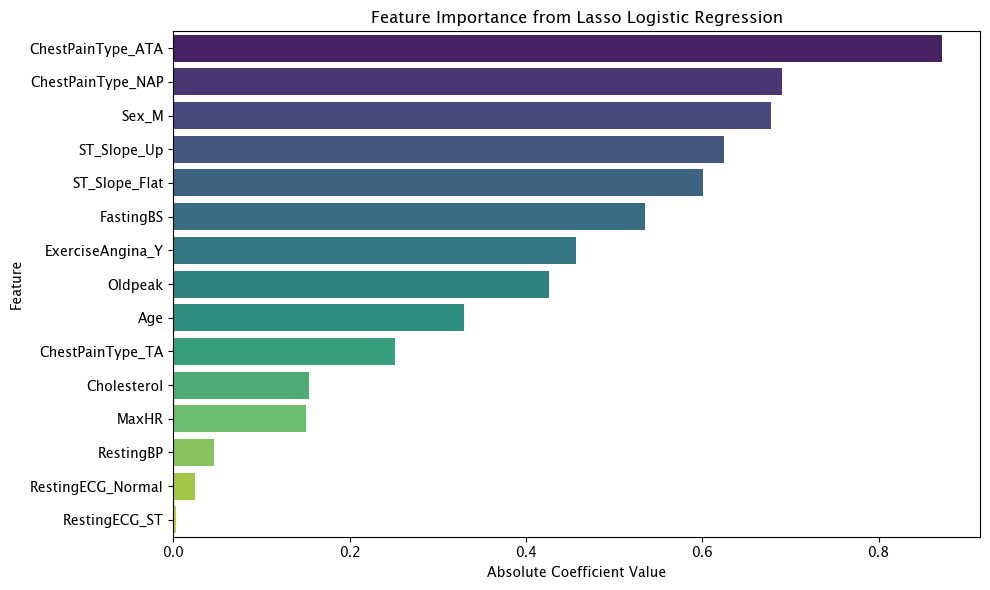

In [6]:
# Extract feature importance from the Lasso model
feature_importance = pd.Series(abs(lasso_model.coef_[0]), index=X_train_val_df.columns)

# Sort feature importance in descending order
feature_importance = feature_importance.sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, dodge=False, palette="viridis", legend=False)
plt.title("Feature Importance from Lasso Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

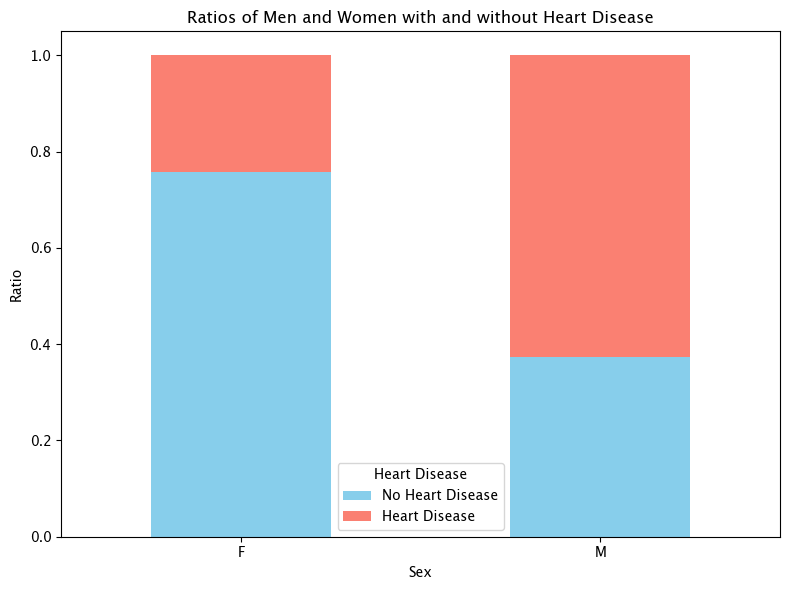

In [7]:
# Group by Sex and HeartDisease to calculate counts
gender_heart_disease_counts = preprocessed_train_val_data.groupby(['Sex', 'HeartDisease']).size().unstack()

# Normalize to get ratios
gender_heart_disease_ratios = gender_heart_disease_counts.div(gender_heart_disease_counts.sum(axis=1), axis=0)

# Plot the ratios
gender_heart_disease_ratios.plot(kind='bar', stacked=True, figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Ratios of Men and Women with and without Heart Disease')
plt.xlabel('Sex')
plt.ylabel('Ratio')
plt.xticks(rotation=0)
plt.legend(['No Heart Disease', 'Heart Disease'], title='Heart Disease')
plt.tight_layout()
plt.show()

### Gender Fair Log. Reg. Model

              precision    recall  f1-score   support

           0       0.69      0.30      0.42        74
           1       0.66      0.91      0.76       110

    accuracy                           0.66       184
   macro avg       0.67      0.60      0.59       184
weighted avg       0.67      0.66      0.62       184

0.6630434782608695
Balanced Accuracy: 0.60
F1-Score: 0.76


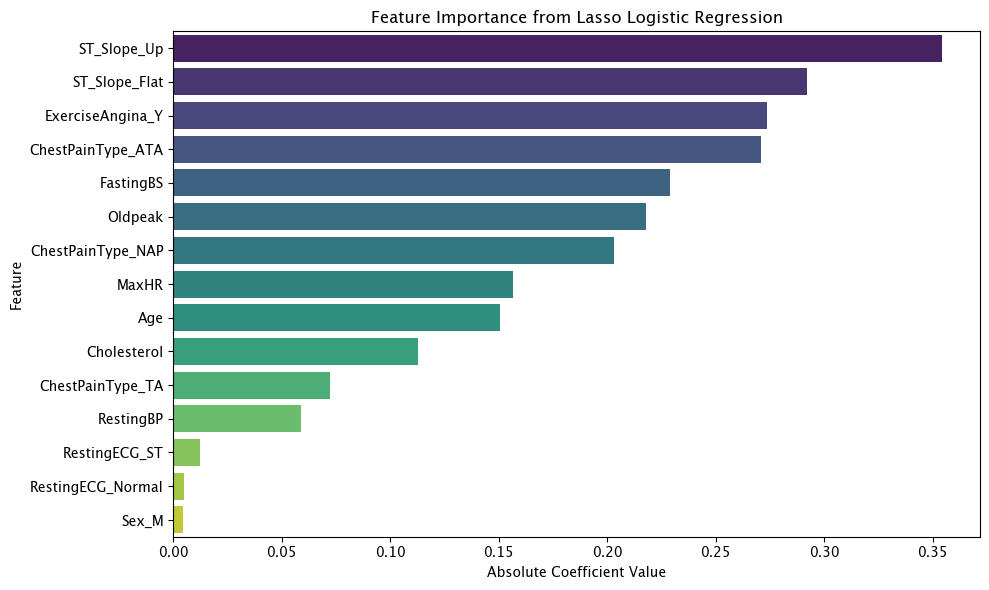

Performance metrics for Sex = M:
              precision    recall  f1-score   support

           0       0.62      0.28      0.39        53
           1       0.70      0.91      0.79        99

    accuracy                           0.69       152
   macro avg       0.66      0.60      0.59       152
weighted avg       0.68      0.69      0.65       152

Balanced Accuracy for Sex = M: 0.60
Performance metrics for Sex = F:
              precision    recall  f1-score   support

           0       0.88      0.33      0.48        21
           1       0.42      0.91      0.57        11

    accuracy                           0.53        32
   macro avg       0.65      0.62      0.53        32
weighted avg       0.72      0.53      0.51        32

Balanced Accuracy for Sex = F: 0.62


In [8]:
gender_weights = np.ones_like(y_train_val.values, dtype=float)  # Convert y_train_val to NumPy array

# Calculate inverse frequencies for (gender, label) groups
for gender_val in [0, 1]:
    for label_val in [0, 1]:
        idx = np.where((gender_train_val == gender_val) & (y_train_val.values == label_val))[0]  # Get valid indices
        freq = len(idx)  # Count the number of occurrences
        if freq > 0:
            gender_weights[idx] = 1.0 / freq

# Fit with sample gender_weights
gender_fair_model = LogisticRegression()
gender_fair_model.fit(X_train_val, y_train_val, sample_weight=gender_weights)
# Evaluate the model
y_pred = gender_fair_model.predict(X_test)
print(classification_report(y_test, y_pred))

print(accuracy_score(y_test, y_pred))
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.2f}")

# Calculate f1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.2f}")

# Extract feature importance from the Lasso model
feature_importance = pd.Series(abs(gender_fair_model.coef_[0]), index=X_train_val_df.columns)

# Sort feature importance in descending order
feature_importance = feature_importance.sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index, dodge=False, palette="viridis", legend=False)
plt.title("Feature Importance from Lasso Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Add the predicted values to the test data
test_data['Predicted'] = y_pred.flatten().astype(int)

# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")

5. **Model Comparison**  
    - Discuss the pros/cons of using Logistic Regression on selected variables (Q2.5. [1 Pt]): 

Selecting features with Lasso simplifies the model and improves interpretability.
However, if feature selection and retraining happen on the same data, it can cause overfitting and biased results.
Feature selection should be done inside cross-validation to avoid this issue.
Sex (Male) being one of the most important features means male participants in this dataset are associated with a higher probability of heart disease in this population. In a causal model, we would want to be careful: we should not conclude "male → heart disease" without adjusting for mediators and confounders like smoking, stress, activity levels, etc.


### Q3: Multi-Layer Perceptrons (5 Pts)
1. **Model Implementation**  
    - Implement and train an MLP, report test performance (Q3.1. [2 Pt]).


In [9]:
# Define the MLP model with dropout
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.2)

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2)

        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

train_val_data, test_data = load_data()
X, y = get_x_y(train_val_data)
X_test, y_test = get_x_y(test_data)
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=29)

X_train = pd.get_dummies(X_train, drop_first=False)
X_val = pd.get_dummies(X_val, drop_first=False)
X_test = pd.get_dummies(X_test, drop_first=False)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Prepare data for PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Initialize the model
input_size = X_train.shape[1]
mlp_model = MLP(input_size)

# Loss function and optimizer with weight decay
criterion = nn.BCELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

# Set random seed for reproducibility
torch.manual_seed(42)

# Train the model
epochs = 100
for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    # Validation
    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Evaluate the model on the validation set
mlp_model.eval()
with torch.no_grad():
    y_val_pred = (mlp_model(X_val_tensor) > 0.5).numpy()
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2f}")
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
print(f"Validation Balanced Accuracy: {balanced_acc:.2f}")
# Calculate f1-score
f1 = f1_score(y_val, y_val_pred)
print(f"Validation F1-Score: {f1:.2f}")

# Evaluate the model on the test set
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
mlp_model.eval()
with torch.no_grad():
    y_test_pred = (mlp_model(X_test_tensor) > 0.5).numpy()
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
print(f"Test Balanced Accuracy: {balanced_acc:.2f}")
# Calculate f1-score
f1 = f1_score(y_test, y_test_pred)
print(f"Test F1-Score: {f1:.2f}")

# Add the predicted values to the test data
test_data['Predicted'] = y_test_pred.flatten().astype(int)
# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")


Epoch 10/100, Loss: 0.6541, Val Loss: 0.6466
Epoch 20/100, Loss: 0.5853, Val Loss: 0.5775
Epoch 30/100, Loss: 0.5016, Val Loss: 0.4928
Epoch 40/100, Loss: 0.4085, Val Loss: 0.4127
Epoch 50/100, Loss: 0.3535, Val Loss: 0.3639
Epoch 60/100, Loss: 0.3303, Val Loss: 0.3444
Epoch 70/100, Loss: 0.3065, Val Loss: 0.3371
Epoch 80/100, Loss: 0.2930, Val Loss: 0.3342
Epoch 90/100, Loss: 0.2895, Val Loss: 0.3333
Epoch 100/100, Loss: 0.2693, Val Loss: 0.3324
Validation Accuracy: 0.88
Validation Balanced Accuracy: 0.87
Validation F1-Score: 0.89
Test Accuracy: 0.84
Test Balanced Accuracy: 0.82
Test F1-Score: 0.87
Performance metrics for Sex = M:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        53
           1       0.85      0.93      0.89        99

    accuracy                           0.85       152
   macro avg       0.85      0.81      0.83       152
weighted avg       0.85      0.85      0.84       152

Balanced Accuracy for Sex = M: 0.

### Gender Fair MLP Model

In [10]:
# Define the MLP model with dropout
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.2)

        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2)

        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

train_val_data, test_data = load_data()
X, y = get_x_y(train_val_data)
X_test, y_test = get_x_y(test_data)
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=29)

# One-hot encode categorical variables
X_train_df = pd.get_dummies(X_train, drop_first=False)
X_val_df = pd.get_dummies(X_val, drop_first=False)
X_test_df = pd.get_dummies(X_test, drop_first=False)

gender_train = X_train_df["Sex_M"].values  # Still a DataFrame here

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val = scaler.transform(X_val_df)
X_test = scaler.transform(X_test_df)

gender_weights = np.ones_like(y_train.values, dtype=float)  # Convert y_train_val to NumPy array

# Calculate inverse frequencies for (gender, label) groups
for gender_val in [0, 1]:
    for label_val in [0, 1]:
        idx = np.where((gender_train == gender_val) & (y_train.values == label_val))[0]  # Get valid indices
        freq = len(idx)  # Count the number of occurrences
        if freq > 0:
            gender_weights[idx] = 1.0 / freq

# Prepare data for PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
weights_tensor = torch.tensor(gender_weights, dtype=torch.float32).unsqueeze(1)  # shape (N, 1)

# Initialize the model
input_size = X_train.shape[1]
gender_fair_mlp_model = MLP(input_size)

# Loss function and optimizer with weight decay
criterion = nn.BCEWithLogitsLoss(reduction='none')
optimizer = optim.Adam(gender_fair_mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

# Set random seed for reproducibility
torch.manual_seed(29)

# Train the model
epochs = 100
for epoch in range(epochs):
    gender_fair_mlp_model.train()
    optimizer.zero_grad()
    outputs = gender_fair_mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    weighted_loss = (loss * weights_tensor).mean()
    weighted_loss.backward()
    optimizer.step()

    # Validation
    gender_fair_mlp_model.eval()
    with torch.no_grad():
        val_outputs = gender_fair_mlp_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)

    if (epoch + 1) % 10 == 0:
        mean_val_loss = val_loss.mean().item()  # Compute the mean of the validation loss
        print(f"Epoch {epoch+1}/{epochs}, Loss: {weighted_loss.item():.4f}, Val Loss: {mean_val_loss:.4f}")

# Evaluate the model on the validation set
gender_fair_mlp_model.eval()
with torch.no_grad():
    y_val_pred = (gender_fair_mlp_model(X_val_tensor) > 0.5).numpy()
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_accuracy:.2f}")
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
print(f"Validation Balanced Accuracy: {balanced_acc:.2f}")
# Calculate f1-score
f1 = f1_score(y_val, y_val_pred)
print(f"Validation F1-Score: {f1:.2f}")

# Evaluate the model on the test set
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
gender_fair_mlp_model.eval()
with torch.no_grad():
    y_test_pred = (gender_fair_mlp_model(X_test_tensor) > 0.5).numpy()
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nTest Accuracy: {test_accuracy:.2f}")
balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
print(f"Test Balanced Accuracy: {balanced_acc:.2f}")
# Calculate f1-score
f1 = f1_score(y_test, y_test_pred)
print(f"Test F1-Score: {f1:.2f}")

# Add the predicted values to the test data
test_data['Predicted'] = y_test_pred.flatten().astype(int)
# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")



Epoch 10/100, Loss: 0.0049, Val Loss: 0.6884
Epoch 20/100, Loss: 0.0048, Val Loss: 0.6808
Epoch 30/100, Loss: 0.0047, Val Loss: 0.6709
Epoch 40/100, Loss: 0.0046, Val Loss: 0.6583
Epoch 50/100, Loss: 0.0045, Val Loss: 0.6442
Epoch 60/100, Loss: 0.0044, Val Loss: 0.6307
Epoch 70/100, Loss: 0.0043, Val Loss: 0.6189
Epoch 80/100, Loss: 0.0043, Val Loss: 0.6088
Epoch 90/100, Loss: 0.0042, Val Loss: 0.5995
Epoch 100/100, Loss: 0.0041, Val Loss: 0.5914

Validation Accuracy: 0.82
Validation Balanced Accuracy: 0.83
Validation F1-Score: 0.83

Test Accuracy: 0.80
Test Balanced Accuracy: 0.81
Test F1-Score: 0.82
Performance metrics for Sex = M:
              precision    recall  f1-score   support

           0       0.65      0.85      0.74        53
           1       0.90      0.76      0.82        99

    accuracy                           0.79       152
   macro avg       0.78      0.80      0.78       152
weighted avg       0.82      0.79      0.79       152

Balanced Accuracy for Sex = M: 


2. **SHAP Explanations**  
    - Visualize SHAP outputs for two positive/negative samples and overall feature importance (Q3.2. [2 Pt]).


In [11]:
# SHAP explanations
explainer = shap.DeepExplainer(gender_fair_mlp_model, X_train_tensor)
shap_values = explainer.shap_values(X_val_tensor)

shap.initjs()
# Convert SHAP values to match the feature names
shap_values = np.array(shap_values).squeeze()  # Remove extra dimensions if necessary

pos_indices = (y_val_tensor.squeeze() == 1).nonzero(as_tuple=True)[0]
neg_indices = (y_val_tensor.squeeze() == 0).nonzero(as_tuple=True)[0]

# Convert sample tensors to numpy
positive_samples = X_val_tensor[pos_indices].numpy()
negative_samples = X_val_tensor[neg_indices].numpy()

feature_names = X_train_val_df.columns.tolist()

print("Positive sample 1:")
shap.force_plot(explainer.expected_value[0], shap_values[pos_indices[0]], positive_samples[0], feature_names=feature_names)

Positive sample 1:


In [12]:
print("Positive sample 2:")
sample_nr = 1
shap.force_plot(explainer.expected_value[0], shap_values[pos_indices[sample_nr]], positive_samples[sample_nr], feature_names=feature_names)


Positive sample 2:


In [13]:
print("Negative sample 1:")
shap.force_plot(explainer.expected_value[0], shap_values[neg_indices[0]], negative_samples[0], feature_names=feature_names)

Negative sample 1:


In [14]:
print("Negative sample 2:")
shap.force_plot(explainer.expected_value[0], shap_values[neg_indices[1]], negative_samples[1], feature_names=feature_names)

Negative sample 2:


torch.Size([147, 20]) (734, 11)


/var/folders/8d/l7s43m1d1vqb0nbp4jhnrkjm0000gn/T/ipykernel_21192/3145473136.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_tensor.numpy(), feature_names=X_train_df.columns)


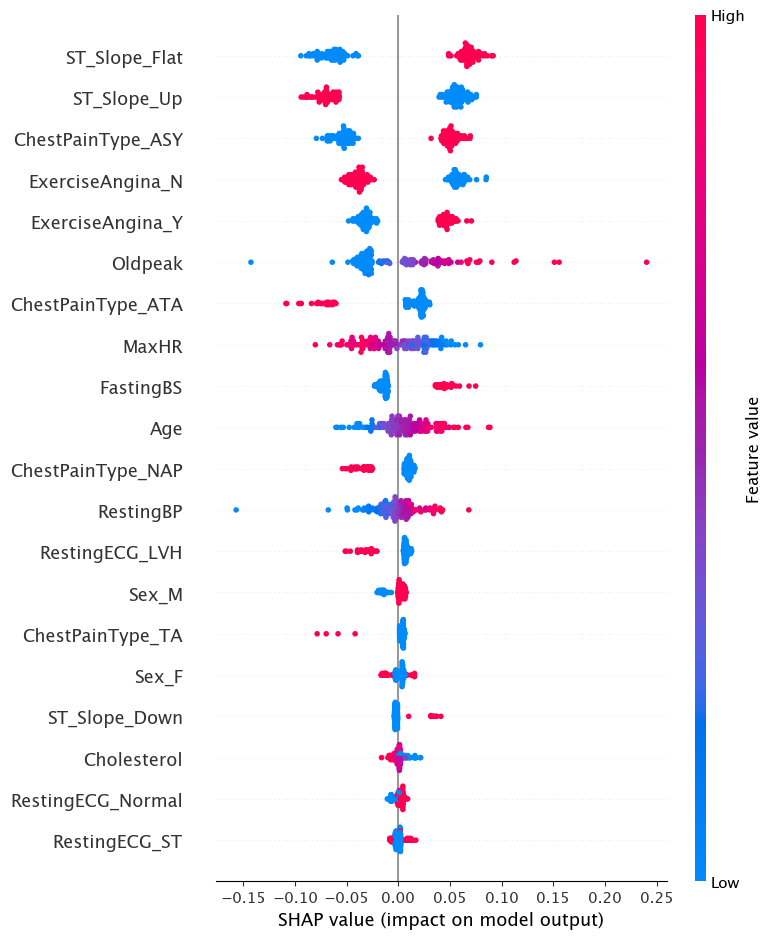

In [15]:
print(X_val_tensor.shape, X.shape)
# Visualize overall feature importance
shap.summary_plot(shap_values, X_val_tensor.numpy(), feature_names=X_train_df.columns)


3. **Feature Importance Consistency**  
    - Analyze consistency across predictions and overall importance (Q3.3. [1 Pt]). 

ChestPainType_ATA, ST_Slope_Flat are still indicators for heart failure. they play an important role in detecting heart failure in the patient. We also see how ChestPain_NAP and FastingBS have a big influence in inferring the target aswell. overall they do add up to very similar feature importance weights as in LogReg



### Q4: Neural Additive Models (7 Pts)
1. **Model Implementation**  
    - Read the NAM paper, implement the model, and train it (Q4.1. [3 Pt]).
    - Provide test set performance metrics.


In [16]:
class FeatureNN(layers.Layer):
    """Neural network for a single feature in Neural Additive Model."""
    
    def __init__(self, hidden_layers_dims, activation='relu', dropout_rate=0.0,
                 l2_regularization=1e-3, name=None):
        """
        Initialize a feature neural network.
        
        Args:
            hidden_layers_dims: List of integers, dimensions of hidden layers
            activation: Activation function to use
            dropout_rate: Float, dropout rate for regularization
            l2_regularization: Float, L2 regularization strength
            name: String, name of the layer
        """
        super(FeatureNN, self).__init__(name=name)
        
        self.hidden_layers = []
        self.dropout_layers = []
        
        # Create hidden layers
        for dim in hidden_layers_dims:
            self.hidden_layers.append(
                layers.Dense(
                    dim, 
                    activation=activation,
                    kernel_regularizer=regularizers.l2(l2_regularization)
                )
            )
            self.hidden_layers.append(layers.BatchNormalization())
            if dropout_rate > 0:
                self.dropout_layers.append(layers.Dropout(dropout_rate))
        
        # Output layer (scalar output with no activation)
        self.output_layer = layers.Dense(
            1, 
            activation=None,
            kernel_regularizer=regularizers.l2(l2_regularization)
        )
    
    def call(self, inputs, training=False):
        """Forward pass for this feature network."""
        x = inputs
        
        # Apply hidden layers with dropout
        for i, hidden_layer in enumerate(self.hidden_layers):
            x = hidden_layer(x)
            if i < len(self.dropout_layers):
                x = self.dropout_layers[i](x, training=training)
                
        # Apply output layer
        return self.output_layer(x)


class NeuralAdditiveModel(models.Model):
    """Neural Additive Model implementation."""
    
    def __init__(self, num_features, hidden_layers_dims=[64, 32], 
                 activation='relu', dropout_rate=0.2, l2_regularization=1e-4,
                 feature_output_regularization=0.0):
        """
        Initialize a Neural Additive Model.
        
        Args:
            num_features: Integer, number of input features
            hidden_layers_dims: List of integers, dimensions of hidden layers for each feature network
            activation: Activation function to use
            dropout_rate: Float, dropout rate for regularization
            l2_regularization: Float, L2 regularization strength for weights
            feature_output_regularization: Float, regularization strength for feature outputs
        """
        super(NeuralAdditiveModel, self).__init__()
        
        # Create a separate neural network for each feature
        self.feature_nns = []
        for i in range(num_features):
            self.feature_nns.append(
                FeatureNN(
                    hidden_layers_dims=hidden_layers_dims,
                    activation=activation,
                    dropout_rate=dropout_rate,
                    l2_regularization=l2_regularization,
                    name=f"feature_nn_{i}"
                )
            )
        
        # Bias term (intercept)
        self.bias = tf.Variable(0.0, name="bias", trainable=True)
        
        # Save configuration for later use
        self.num_features = num_features
        self.feature_output_regularization = feature_output_regularization
    
    def call(self, inputs, training=False):
        """Forward pass for the NAM."""
        # Split input tensor along the feature dimension
        # Each feature gets its own neural network
        feature_outputs = []
        
        # Process each feature with its own neural network
        for i in range(self.num_features):
            # Extract the i-th feature and reshape it to (batch_size, 1)
            feature_input = tf.expand_dims(inputs[:, i], axis=-1)
            feature_output = self.feature_nns[i](feature_input, training=training)
            feature_outputs.append(feature_output)
        
        # Sum all feature outputs
        sum_outputs = tf.add_n(feature_outputs)
        
        logits = sum_outputs + self.bias
        self.add_loss(self.regularization_loss())
        return tf.sigmoid(logits)  # Probability output

    
    def get_feature_output(self, inputs, feature_idx):
        """Get the output of a specific feature network."""
        feature_input = tf.expand_dims(inputs[:, feature_idx], axis=-1)
        return self.feature_nns[feature_idx](feature_input, training=False)
    
    def regularization_loss(self):
        """Calculate the regularization loss for feature outputs."""
        if self.feature_output_regularization <= 0:
            return 0.0
        
        reg_loss = 0.0
        for fn in self.feature_nns:
            for weight in fn.trainable_weights:
                reg_loss += tf.reduce_sum(tf.square(weight))
        
        return self.feature_output_regularization * reg_loss

class NAMTrainer:
    """Class to train and evaluate a Neural Additive Model."""
    
    def __init__(self, num_features, hidden_layers_dims=[64, 32], 
                 activation='relu', dropout_rate=0.25, l2_regularization=1e-2,
                 feature_output_regularization=0.001, lr=1e-3):
        """
        Initialize a NAM trainer.
        
        Args:
            num_features: Integer, number of input features
            hidden_layers_dims: List of integers, dimensions of hidden layers for each feature network
            activation: Activation function to use
            dropout_rate: Float, dropout rate for regularization
            l2_regularization: Float, L2 regularization strength for weights
            feature_output_regularization: Float, regularization strength for feature outputs
            learning_rate: Float, learning rate for the optimizer
        """
        self.model = NeuralAdditiveModel(
            num_features=num_features,
            hidden_layers_dims=hidden_layers_dims,
            activation=activation,
            dropout_rate=dropout_rate,
            l2_regularization=l2_regularization,
            feature_output_regularization=feature_output_regularization
        )
        
        self.optimizer = optimizers.Adam(learning_rate=lr)
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.feature_names = None
        self.scaler = StandardScaler()
        
    def compile(self, optimizer=None, metrics=None):
        """Compile the model with specified loss function, optimizer, and metrics."""
        if optimizer is not None:
            self.optimizer = optimizer
            
        self.model.compile(
            loss=self.loss_fn,
            optimizer=self.optimizer,
            metrics=metrics
        )
        
    def fit(self, X, y, sample_weight=None, feature_names=None, batch_size=32, 
            epochs=100, validation_split=0.2, patience=5, verbose=1):
        """
        Train the NAM on the given data.
        
        Args:
            X: Input features
            y: Target values
            sample_weight: Optional array of weights for each sample
            feature_names: List of feature names for plotting
            batch_size: Integer, batch size
            epochs: Integer, number of epochs
            validation_split: Float, fraction of data to use for validation
            patience: Integer, patience for early stopping
            verbose: Integer, verbosity mode
            
        Returns:
            History object from training
        """
        # Scale the inputs
        X_scaled = self.scaler.fit_transform(X)

        # Save feature names for plotting
        self.feature_names = feature_names if feature_names else [f"Feature {i}" for i in range(X.shape[1])]

        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_acc', mode='max', patience=patience, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_acc', mode='max', factor=0.5, patience=patience // 2, verbose=verbose)
        ]

        # Train the model
        history = self.model.fit(
            X_scaled, y,
            sample_weight=sample_weight,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=verbose
        )

        return history

    
    def predict(self, X):
        """Generate predictions for the input samples."""
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)
    
    def evaluate(self, X, y, sample_weight=None):
        """Evaluate the model on the test data."""
        X_scaled = self.scaler.transform(X)
        return self.model.evaluate(X_scaled, y, sample_weight=sample_weight)

    
    def plot_feature_shapes(self, X, feature_idx=None, num_points=1000, figsize=(15, 10)):
        """
        Plot the shape functions learned by the model.
        
        Args:
            X: Input features (used to determine feature ranges)
            feature_idx: List of feature indices to plot (None for all)
            num_points: Number of points to use for plotting
            figsize: Figure size
        """
        # Scale original data to get proper ranges
        X_scaled = self.scaler.transform(X)
        
        # Determine which features to plot
        if feature_idx is None:
            feature_idx = range(X.shape[1])
        
        # Create a figure
        n_features = len(feature_idx)
        n_cols = min(3, n_features)
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for i, idx in enumerate(feature_idx):
            if i >= len(axes):
                break
                
            # Create synthetic feature values spanning the range of this feature
            feature_min = np.min(X_scaled[:, idx])
            feature_max = np.max(X_scaled[:, idx])
            feature_range = np.linspace(feature_min, feature_max, num_points)
            
            # Create input where only this feature varies
            X_synth = np.zeros((num_points, X.shape[1]))
            X_synth[:, idx] = feature_range
            
            # Get model predictions for this feature
            feature_contribution = self.model.get_feature_output(X_synth, idx).numpy().flatten()
            
            # Get original feature values (before scaling)
            orig_feature_range = self.scaler.inverse_transform(X_synth)[:, idx]
            
            # Plot
            axes[i].plot(orig_feature_range, feature_contribution)
            axes[i].set_title(self.feature_names[idx])
            axes[i].axhline(y=0, color='r', linestyle='-', alpha=0.3)
            axes[i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        return fig
    
    def feature_importance(self, X):
        """
        Calculate feature importance based on the range of outputs for each feature.
        
        Args:
            X: Input features
            
        Returns:
            Dictionary mapping feature names to importance scores
        """
        X_scaled = self.scaler.transform(X)
        importance = {}
        
        for i in range(X.shape[1]):
            # Get outputs for this feature
            feature_input = tf.expand_dims(X_scaled[:, i], axis=-1)
            feature_output = self.model.feature_nns[i](feature_input).numpy().flatten()
            
            # Calculate importance as range of the feature's contribution
            importance[self.feature_names[i]] = np.max(feature_output) - np.min(feature_output)
            
        # Normalize importances
        total = sum(importance.values())
        if total > 0:
            for key in importance:
                importance[key] /= total
                
        return importance

def set_seed(seed=29):
    np.random.seed(seed)                      # NumPy
    tf.random.set_seed(seed)                  # TensorFlow


Epoch 1/50


2025-05-08 16:51:15.663427: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-05-08 16:51:15.664427: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

11/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4846 - loss: 6.1390  

2025-05-08 16:51:29.006734: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-05-08 16:51:29.007058: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.4845 - loss: 6.0851 - val_accuracy: 0.5102 - val_loss: 4.2758 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6148 - loss: 5.1177 - val_accuracy: 0.6939 - val_loss: 4.0465 - learning_rate: 0.0010
Epoch 3/50
 1/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6562 - loss: 4.5887

/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6688 - loss: 4.7412 - val_accuracy: 0.7211 - val_loss: 3.9045 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6912 - loss: 4.4978 - val_accuracy: 0.7007 - val_loss: 3.8329 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7612 - loss: 4.2260 - val_accuracy: 0.7075 - val_loss: 3.7853 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7672 - loss: 4.2301 - val_accuracy: 0.6939 - val_loss: 3.7327 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7733 - loss: 4.0299 - val_accuracy: 0.7143 - val_loss: 3.6518 - learning_rate: 0.0010
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7735 - loss: 3.7992 - val_accuracy: 0.7143 - val_loss: 3.5950 - learning_rate: 0.0010
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7961 - loss: 3.5705 - val_accuracy: 0.7075 - va

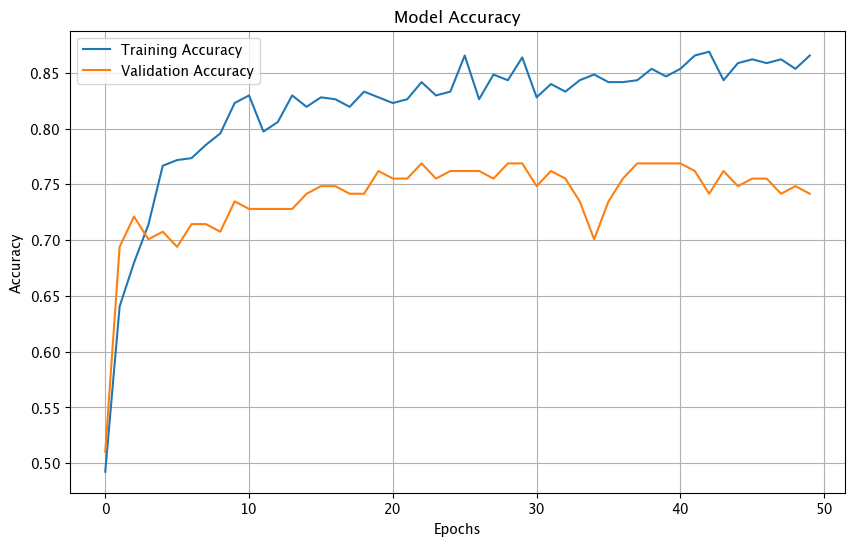

2025-05-08 16:51:39.367691: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-05-08 16:51:39.368083: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step

Test Accuracy: 0.67
Test Balanced Accuracy: 0.63
Test F1-Score: 0.75
Performance metrics for Sex = M:
              precision    recall  f1-score   support

           0       0.57      0.43      0.49        53
           1       0.73      0.83      0.78        99

    accuracy                           0.69       152
   macro avg       0.65      0.63      0.64       152
weighted avg       0.68      0.69      0.68       152

Balanced Accuracy for Sex = M: 0.63
Performance metrics for Sex = F:
              precision    recall  f1-score   support

           0       0.77      0.48      0.59        21
           1       0.42      0.73      0.53        11

    accuracy                           0.56        32
   macro avg       0.60      0.60      0.56        32
weighted avg       0.65      0.56      0.57        32

Balanced Accuracy for Sex = F: 0.60


In [17]:
train_val_data, test_data = load_data()
preprocessed_train_val_data, preprocessed_test_data = preprocess_data(train_val_data, test_data)

X_train_val, y_train_val = get_x_y(preprocessed_train_val_data)
X_test, y_test = get_x_y(preprocessed_test_data)

# Standardize the features
scaler = StandardScaler()

# One-hot encode categorical variables
X_train_val = pd.get_dummies(X_train_val, drop_first=False)
X_test = pd.get_dummies(X_test, drop_first=False)

# Prepare train/test split
# X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2)
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

feature_names = X_train_val.columns.tolist()

# Initialize the NAM trainer
nam_trainer = NAMTrainer(
    num_features=X_train_val.shape[1],
    hidden_layers_dims=[16, 8],
    activation='relu',
    dropout_rate=0.25,
    l2_regularization=1e-2,
    lr=1e-3,
)

# Compile for binary classification
nam_trainer.compile(optimizer='adam', metrics=['accuracy'])

# Train the model
history = nam_trainer.fit(
    X_train_val, y_train_val,
    feature_names=feature_names,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    patience=5,
    #sample_weight=gender_weights
)

# Plot training/validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predict probabilities on test set
y_test_pred = nam_trainer.predict(X_test)
# Convert probabilities to binary predictions using a threshold of 0.5
y_test_pred_binary = (y_test_pred > 0.5).astype(int)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred_binary)
print(f"\nTest Accuracy: {test_accuracy:.2f}")

balanced_acc = balanced_accuracy_score(y_test, y_test_pred_binary)
print(f"Test Balanced Accuracy: {balanced_acc:.2f}")

# Calculate f1-score
f1 = f1_score(y_test, y_test_pred_binary)
print(f"Test F1-Score: {f1:.2f}")

# Add the predicted values to the test data
test_data['Predicted'] = y_test_pred_binary.flatten().astype(int)

# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")

/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


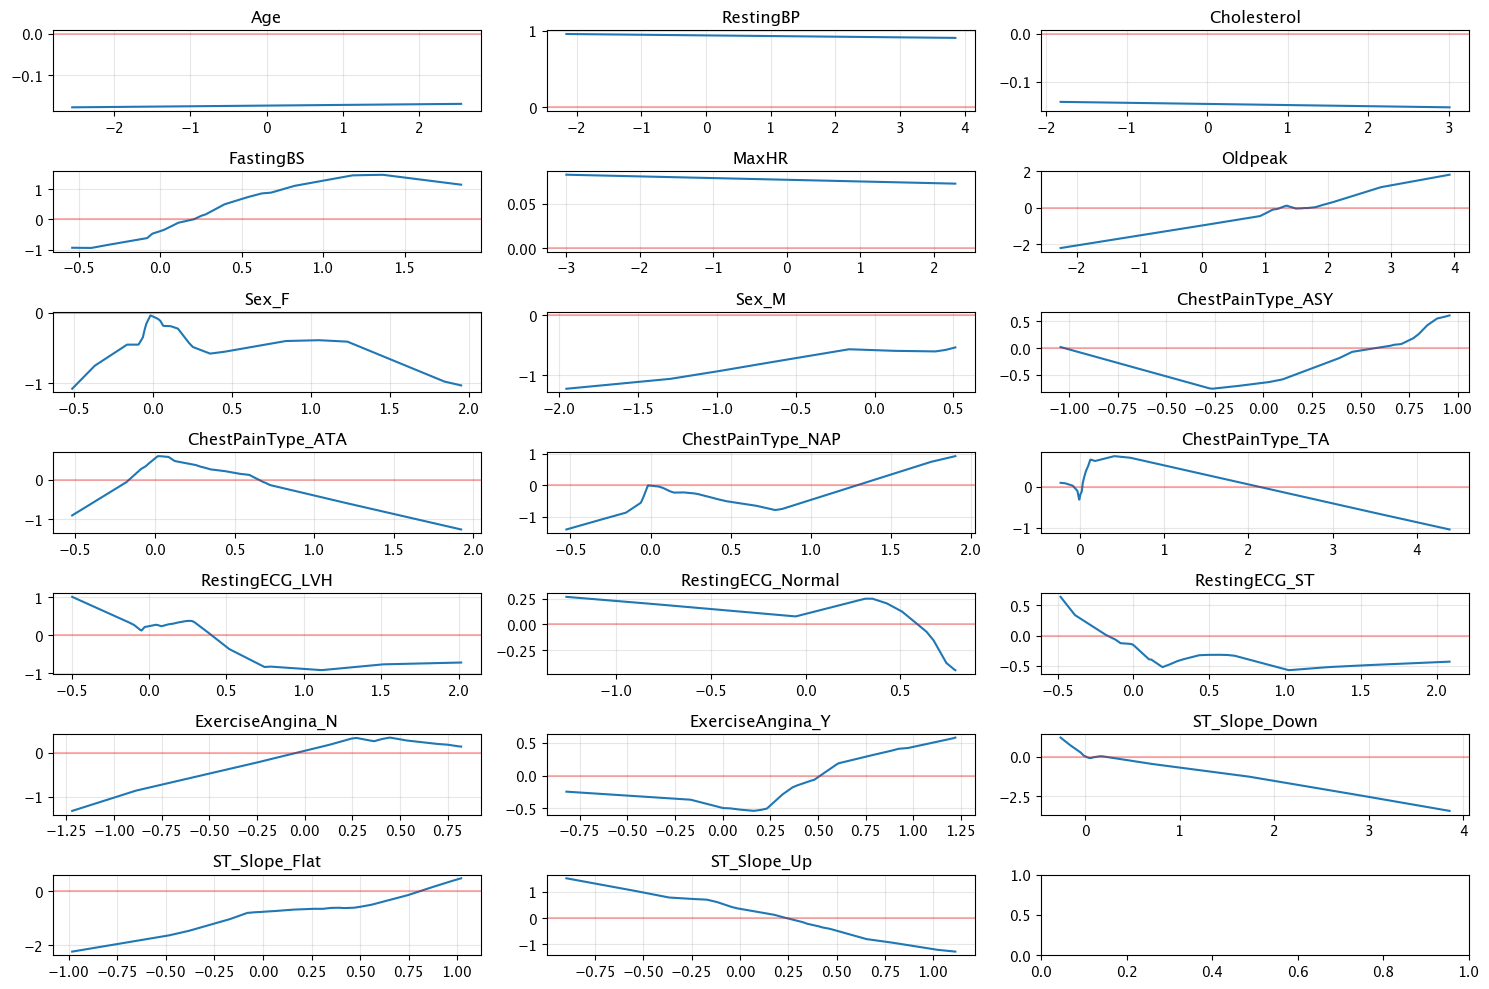

In [18]:
nam_trainer.plot_feature_shapes(X_train)

# Plot feature importance
importance = nam_trainer.feature_importance(X_train)

#### Gender fair NAM

In [ ]:
set_seed(29)
gender_weights = np.ones_like(y_train_val.values, dtype=float)  # Convert y_train_val to NumPy array

# Calculate inverse frequencies for (gender, label) groups
for gender_val in [0, 1]:
    for label_val in [0, 1]:
        idx = np.where((gender_train_val == gender_val) & (y_train_val.values == label_val))[0]  # Get valid indices
        freq = len(idx)  # Count the number of occurrences
        if freq > 0:
            gender_weights[idx] = 1.0 / freq

# Initialize the NAM trainer
nam_trainer = NAMTrainer(
    num_features=X_train_val.shape[1],
    hidden_layers_dims=[16, 8],
    activation='relu',
    dropout_rate=0.25,
    l2_regularization=1e-2,
    lr=1e-3,
)
# Compile for binary classification
nam_trainer.compile(optimizer='adam', metrics=['accuracy'])

# Train the model
history = nam_trainer.fit(
    X_train_val, y_train_val,
    feature_names=feature_names,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    patience=2,
    sample_weight=gender_weights
)

# Plot training/validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Predict probabilities on test set
y_test_pred = nam_trainer.predict(X_test)
# Convert probabilities to binary predictions using a threshold of 0.5
y_test_pred_binary = (y_test_pred > 0.5).astype(int)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred_binary)
print(f"\nTest Accuracy: {test_accuracy:.2f}")

balanced_acc = balanced_accuracy_score(y_test, y_test_pred_binary)
print(f"Test Balanced Accuracy: {balanced_acc:.2f}")

# Calculate f1-score
f1 = f1_score(y_test, y_test_pred_binary)
print(f"Test F1-Score: {f1:.2f}")

# Add the predicted values to the test data
test_data['Predicted'] = y_test_pred_binary.flatten().astype(int)

# Group by Sex and calculate classification metrics
for sex in test_data['Sex'].unique():
    print(f"Performance metrics for Sex = {sex}:")
    sex_group = test_data[test_data['Sex'] == sex]
    print(classification_report(sex_group['HeartDisease'], sex_group['Predicted']))
    balanced_acc = balanced_accuracy_score(sex_group['HeartDisease'], sex_group['Predicted'])
    print(f"Balanced Accuracy for Sex = {sex}: {balanced_acc:.2f}")

Epoch 1/50



2. **Feature Importance Visualization**  
    - Utilize NAM interpretability to visualize feature importance (Q4.2. [2 Pt]).


/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/rabbit/Desktop/ETH/2_Healthcare_ML/hcml_projects/task_2/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


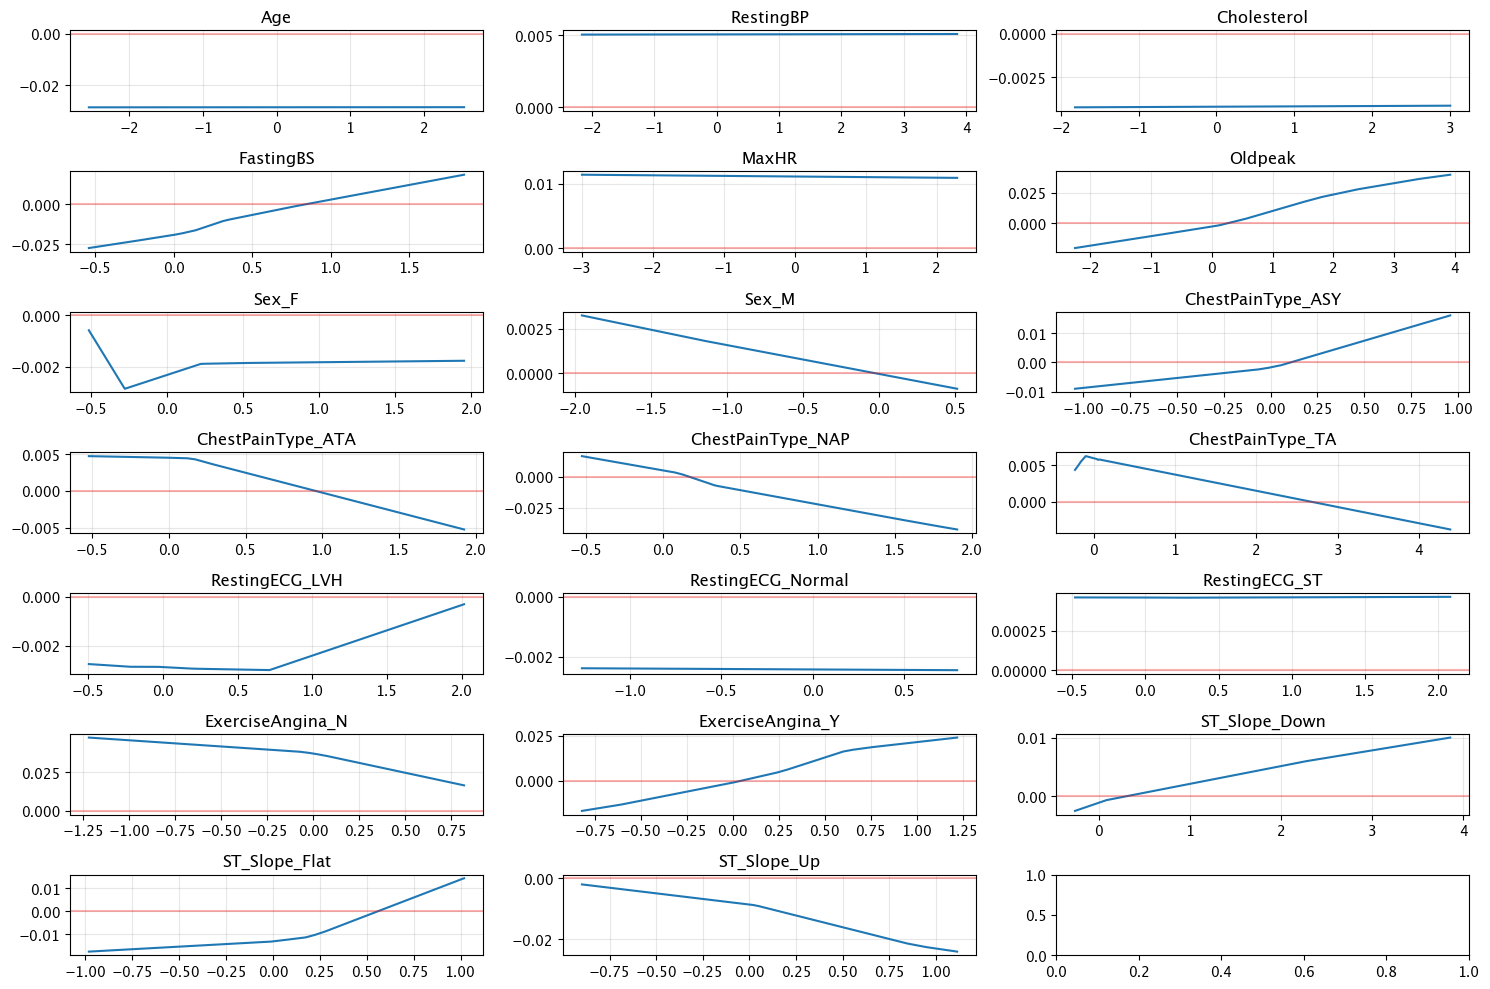

In [ ]:
nam_trainer.plot_feature_shapes(X_train)

# Plot feature importance
importance = nam_trainer.feature_importance(X_train)


3. **Model Comparison**  
    - Compare NAMs to Logistic Regression and MLPs conceptually (Q4.3. [1 Pt]).
4. **Interpretability of NAMs**  
    - Explain why NAMs are more interpretable than MLPs (Q4.4. [1 Pt]).
